### ASTR 3300/5300: Astrostatistics
***N. Pol***
___

# Homework 2
### Due: Monday, Sep. 21 at 11.59pm CST
---

## Problem 1

This question is about Monte Carlo integration. A standard Gaussian integral takes the form 

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

1) Write down the usual form of a Gaussian distribution with $\mu=0$ and $\sigma=\sigma$ that is normalized between $\infty$ and $+\infty$. What is the corresponding form of a half-Gaussian distribution between $0$ and $+\infty$? (Remember that the half-Gaussian distribution must be normalized such that it integrates to one.)

2) Manipulate the above equation such that you can write the left hand side in terms of a normalized half-Gaussian distribution. 

3) Draw $N=10^5$ samples from a $\sigma=3$ normal distribution, mask the samples such that only positive values are accepted, then perform Monte Carlo integration using your equation in (2). Confirm that this *approximately* matches the value computed from the right hand side of the equation. If you don't get approximately matching values then you may have forgotten normalization factors for the Gaussian, or constant factors from translating a normalized Gaussian to a half-Gaussian.

4) Repeat (3) for $N=[10^2,10^3,10^4]$, computing the integral using $100$ different batches of random samples for each $N$. Record all calculated values at all $N$. 

5) Make a plot that shows $\log_{10}N$ along the $x$-axis and the spread between the maximum and minimum Monte Carlo integral values that you get at each $N$ on the $y$-axis. (Note: matplotlib's `fill_between` command is useful for this). Plot a horizontal line on the same figure to show the precise mathematical value. You should see that Monte Carlo integration results in less numerical spread as $N$ gets larger.

### Solution

1. usual form of Gaussian distribution:
$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{x^2}{2\sigma^2}\right)
$$
half-Gaussian distribution, between 0 and $\infty$:
$$
f_{\text{half}}(x) = \sqrt{\frac{2}{\pi}}\,\frac{1}{\sigma}\exp\left(-\frac{x^2}{2\sigma^2}\right)
$$

2. solve for exponential factor:
$$
\exp\left(-\frac{x^2}{2\sigma^2}\right) = \sigma\sqrt{\frac{\pi}{2}}\; f_{\text{half}}(x).
$$
plug into given integral:
$$
\int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) dx 
= \sigma\sqrt{\frac{\pi}{2}} \int_0^\infty x^3\, f_{\text{half}}(x)\, dx.
$$
left-hand side equals $2\sigma^4$:
$$
\sigma\sqrt{\frac{\pi}{2}} \int_0^\infty x^3\, f_{\text{half}}(x)\, dx = 2\sigma^4.
$$
rearrange:
$$
\int_0^\infty x^3\, f_{\text{half}}(x)\, dx = 2\sigma^3\sqrt{\frac{2}{\pi}}.
$$

In [90]:
#part 3
import numpy as np

sigma = 3
N = 100000

samples = np.random.normal(loc=0, scale=sigma, size=N) #samples drawn from gaussian

mask = samples > 0 #only take positive samples
masked_samples = samples[mask] #apply mask

N_acc = len(masked_samples) #how many samples were kept
print(f"number of samples drawn:   {N}")
print(f"number accepted:   {N_acc}")

number of samples drawn:   100000
number accepted:   49972


In [91]:
#part 3
x3_mean = np.mean(masked_samples**3) #mean of samples ^3
mc_integral = sigma * np.sqrt(np.pi / 2) * x3_mean #mc equation

right_hand_side = 2 * sigma**4 #right hand side of equation

print(f"Monte Carlo: {mc_integral:.4f}")
print(f"2 sigma^4:   {right_hand_side:.4f}")
print(f"difference:  {abs(mc_integral - right_hand_side)}")

Monte Carlo: 164.0357
2 sigma^4:   162.0000
difference:  2.0357489635565287


In [92]:
#part 4
N_100 = 10**2
n_batches = 100

samples_100 = np.random.normal(loc=0, scale=sigma, size=(n_batches, N_100))

mask_100 = samples_100 > 0

x3_sum_100 = np.where(mask_100, samples_100**3, 0.0).sum(axis=1) #keep sample if it passed mask and sum
n_acc_100 = mask_100.sum(axis=1) #how many samples were kept
x3_mean_100 = x3_sum_100 / n_acc_100 #mean of each batch

results_100 = sigma * np.sqrt(np.pi / 2) * x3_mean_100 #mc equation

print(f"N=100: {results_100}")

N=100: [123.64242722 186.64825712 176.4673261  174.09203162 119.84444118
  90.40944432 211.95813111 364.57231254 140.51436029 225.64433079
 191.29587995 170.36182147 244.31705016 157.82663333 200.86026751
 296.73155203 176.10151923 144.09799379 179.81108361 233.52840006
 167.01255247 175.29009785 197.94218563 280.62092435 184.98638739
 154.74980614 147.05833379  95.95588033 175.58371314 177.57466568
 168.26567306 222.90636005 172.53656879 169.90384074 228.15249373
 192.63893568 132.84518487 100.64803414 281.09563236 265.61275222
  93.96550773 177.64320038 131.91296047  79.35492592 200.75300169
 268.89113007  87.04491185  83.25192746 211.39761879 109.51036299
 105.3892667  157.30795317 194.36120477 205.88974607 206.94782068
 192.5707927  206.86450952 173.92747676 181.88133698  90.8299755
 121.40497158 227.21661356 136.36099131 155.90368244  90.94827118
 175.73275147  88.73617409  68.12081321 211.17260937  85.15092047
 142.14523943 245.52082258 208.93441229 100.24509183 136.96910583
  90

In [93]:
#part 4
N_1000 = 10**3

samples_1000 = np.random.normal(loc=0, scale=sigma, size=(n_batches, N_1000))

mask_1000 = samples_1000 > 0

x3_sum_1000 = np.where(mask_1000, samples_1000**3, 0.0).sum(axis=1)
n_acc_1000 = mask_1000.sum(axis=1)
x3_mean_1000 = x3_sum_1000 / n_acc_1000

results_1000 = sigma * np.sqrt(np.pi / 2) * x3_mean_1000

print(f"N=1000: {results_1000}")

N=1000: [135.1340018  160.01405886 160.49211263 148.95590883 173.53208545
 136.99413002 153.62272459 187.73540075 175.77746633 159.98947531
 160.61729551 162.74936798 173.0409273  155.522269   186.9865847
 154.74586508 152.15777741 173.02782851 171.96878982 170.42520723
 165.56226565 141.185941   184.80821617 159.42909412 151.18195221
 156.61649513 152.55979288 132.54412535 189.90570667 150.82559109
 147.5063418  174.04175136 152.84195185 163.26855138 188.55073238
 154.77610313 165.91955704 147.773767   147.62984498 180.12613696
 166.91924486 159.61775055 155.39142299 152.66723847 150.99268433
 146.41625694 173.97947258 156.2325759  158.90711091 196.61283311
 154.41990176 150.92448936 190.25144741 161.3890561  157.27070922
 163.52382816 171.19223567 152.32205117 142.609495   144.90520129
 186.57756261 138.43772521 176.0388963  175.06759776 184.54348583
 174.55631488 169.99803739 158.0568368  140.41412837 154.8001895
 180.2664518  163.82442819 151.06845169 170.01564675 186.36039077
 167

In [94]:
#part 4
N_10000 = 10**4

samples_10000 = np.random.normal(loc=0, scale=sigma, size=(n_batches, N_10000))

mask_10000 = samples_10000 > 0

x3_sum_10000 = np.where(mask_10000, samples_10000**3, 0.0).sum(axis=1)
n_acc_10000 = mask_10000.sum(axis=1)
x3_mean_10000 = x3_sum_10000 / n_acc_10000

results_10000 = sigma * np.sqrt(np.pi / 2) * x3_mean_10000

print(f"N=10000: {results_10000}")

N=10000: [166.23006961 167.71283319 155.9470454  159.13180453 157.37391941
 165.26011217 162.0745629  168.58768815 154.97564001 159.23450422
 167.93922938 164.96918992 164.89031534 158.78843202 161.41681054
 167.99953279 158.86648472 163.99452476 168.7231435  165.29801365
 159.99143663 157.81982676 167.72076911 163.75420732 167.94972043
 150.17392691 154.40178994 168.00292295 158.16017454 163.37258102
 162.76767844 159.97696133 161.74831982 157.64750808 166.5972303
 160.74284883 166.75637947 159.27237987 157.9861765  162.93885907
 156.35079409 169.94848784 159.15677535 159.27289425 164.12877584
 159.03811528 161.487116   160.84388573 162.31354801 163.27479962
 175.76376552 169.60037405 161.09271151 166.23329596 160.38974242
 159.22757102 174.77378006 155.68780222 167.93235322 158.2165107
 164.67047386 159.59473967 163.59897718 159.11924129 162.38876136
 158.13108091 157.62446942 157.34007306 160.05684264 167.02875326
 153.97782881 162.70246669 163.9586192  158.54992976 170.11094683
 15

In [95]:
#part 4
print(f"N=100:   mean={results_100.mean():.4f}, std={results_100.std():.4f}")
print(f"N=1000:  mean={results_1000.mean():.4f}, std={results_1000.std():.4f}")
print(f"N=10000: mean={results_10000.mean():.4f}, std={results_10000.std():.4f}")

N=100:   mean=167.8205, std=54.7240
N=1000:  mean=161.7990, std=14.9723
N=10000: mean=161.9382, std=4.8075


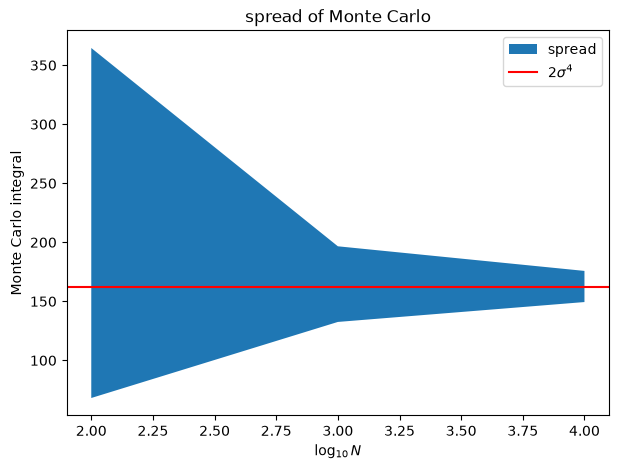

In [96]:
#part 5
import matplotlib.pyplot as plt

#logs of each N
log10_N = np.array([np.log10(N_100), np.log10(N_1000), np.log10(N_10000)])

#minimums and maximums of each result
mins = np.array([results_100.min(), results_1000.min(), results_10000.min()])
maxs = np.array([results_100.max(), results_1000.max(), results_10000.max()])

plt.figure(figsize=(7,5))
plt.fill_between(log10_N, mins, maxs, label='spread')

plt.axhline(right_hand_side, color='red', linestyle='-', label=r'$2\sigma^4$')

plt.xlabel(r'$\log_{10} N$')
plt.ylabel('Monte Carlo integral')
plt.title('spread of Monte Carlo')
plt.legend()
plt.show()

<span style="color:green">NP: correct! </span>

## Problem 2

This question is about IQ. It's a flawed and questionable metric, but useful for this problem. By definition, IQ is calibrated as a Gaussian distribution with $\mu=100$ and $\sigma=15$. 

1) Create a `scipy.stats` Gaussian object with these properties. Plot the distribution, and print out 10 random draws, along with the pdf at $x=145$. 

2) Access the `cdf` property of the Gaussian object and plot it over the same $x$-range as in (1) but in a different figure. Access the `ppf` property (percent point function) and use *inverse transform sampling* of the cdf to draw $10^4$ random samples, and make a histogram of these. Overplot the pdf from (1). These should match.

3) What fraction of people have IQ > 145? *Hint: investigate all the properties of the Gaussian object from (1) to find the relevant property that gives you this, or perform a calculation involving the cdf.*

4) What IQ corresponds to "one in a million"?

### Solution

10 random draws: [117.15951327 109.9472767  123.31892785  95.90526521  91.02477415
 106.71708748  98.51646415 102.78953448  76.56058514  88.11661554]
pdf: 0.0002954565607958672


Text(0.5, 1.0, 'pdf plot')

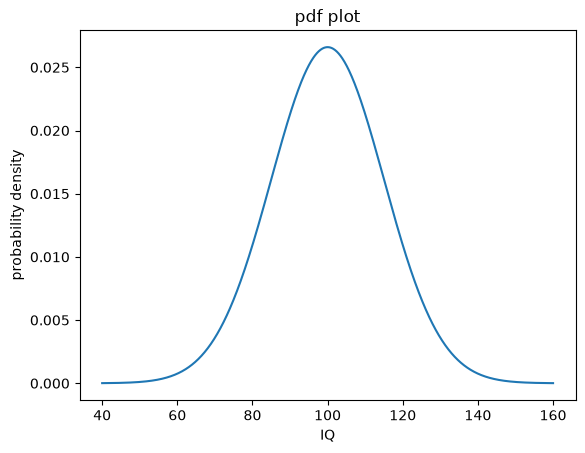

In [97]:
# part 1
from scipy import stats

mu = 100
sigma = 15
iq = stats.norm(loc=mu, scale=sigma) #gaussian

draws = iq.rvs(size=10) #10 draws
print("10 random draws:", draws)

pdf = iq.pdf(145)
print("pdf:", pdf)

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
plt.plot(x, iq.pdf(x))
plt.xlabel("IQ")
plt.ylabel("probability density")
plt.title("pdf plot")

Text(0, 0.5, 'cumulative probability')

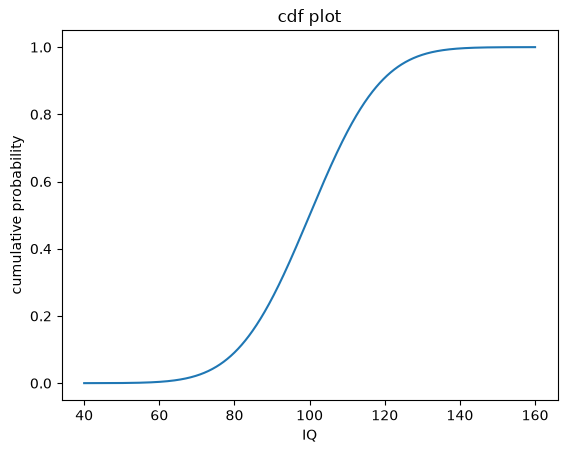

In [98]:
# part 2
plt.plot(x, iq.cdf(x))
plt.title("cdf plot")
plt.xlabel("IQ")
plt.ylabel("cumulative probability")

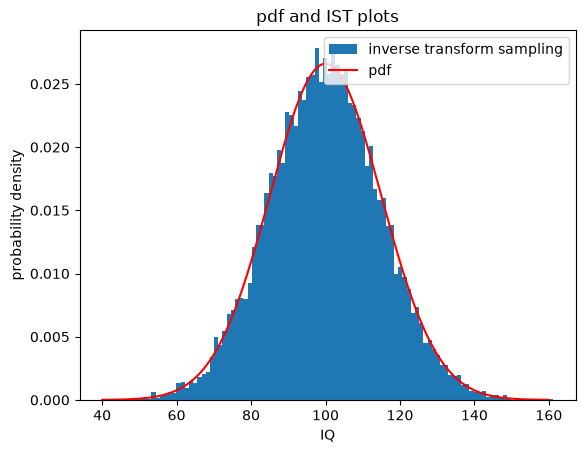

In [99]:
# part 2
rng = np.random.default_rng(42)
u = rng.uniform(0, 1, size=10000) 
samples = iq.ppf(u)

plt.figure()
plt.hist(samples, label="inverse transform sampling", density=True, bins=100)
plt.plot(x, iq.pdf(x), label="pdf", color='red')
plt.legend(loc='upper right')
plt.title("pdf and IST plots")
plt.xlabel("IQ")
plt.ylabel("probability density")
plt.show()

In [100]:
# part 3
print(dir(iq)) #investigating gaussian object
help(stats.norm.sf)
help(stats.norm.isf)

['__annotate_func__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'a', 'args', 'b', 'cdf', 'dist', 'entropy', 'expect', 'interval', 'isf', 'kwds', 'logcdf', 'logpdf', 'logsf', 'mean', 'median', 'moment', 'pdf', 'ppf', 'random_state', 'rvs', 'sf', 'stats', 'std', 'support', 'var']
Help on method sf in module scipy.stats._distn_infrastructure:

sf(x, *args, **kwds) method of scipy.stats._continuous_distns.norm_gen instance
    Survival function (1 - `cdf`) at x of the given RV.

    Parameters
    ----------
    x : array_like
        quantiles
    arg1, arg2, arg3,... : array_like
        The shape parameter(s) f

In [101]:
# part 3
fraction = iq.sf(145)
print("fraction of people with IQ over 145:", fraction)

fraction of people with IQ over 145: 0.0013498980316300933


In [102]:
# part 4
million = iq.isf(1e-6)
print("one in a million IQ:", million)

one in a million IQ: 171.30136463234348


<span style="color:green">NP: correct! </span>

## Problem 3

This question is about Poisson distributions. A famous early application was an analysis of Prussian cavalryman horse-kick deaths by [Bortkiewicz](https://www.wikiwand.com/en/Ladislaus_Bortkiewicz) in 1898. Let's take a short look at the kind of data he analyzed.

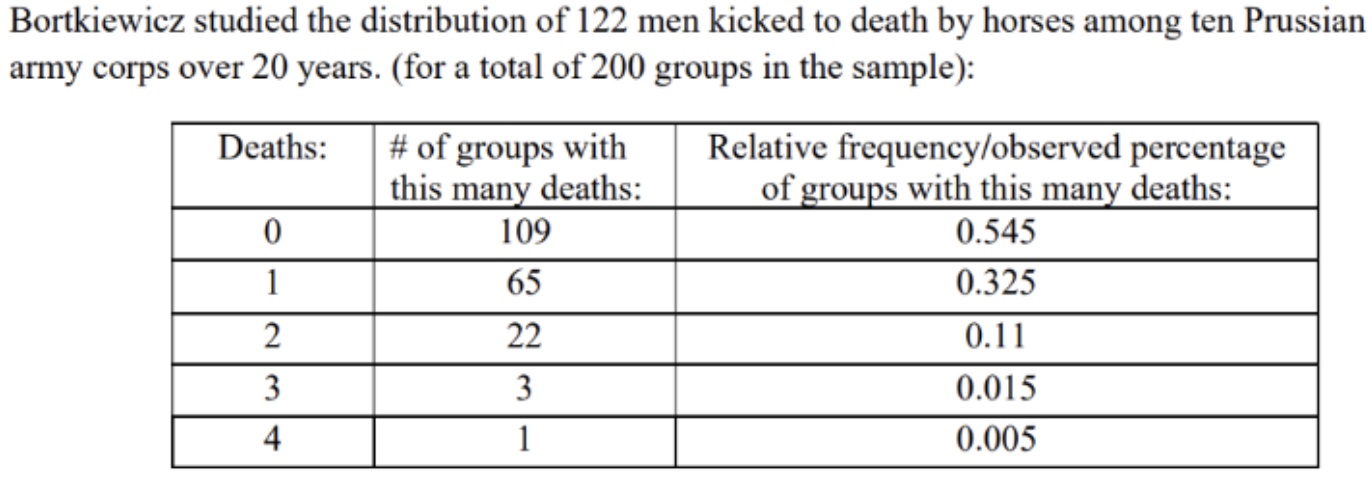

The data essentially consist of 200 total years of Prussian army corps information (i.e. ten army corps over 20 years).

1) Make a plot of the first and third columns of this data.

2) Plot a few Poisson distributions on top that are characterized by different $\mu$ values that might be reasonable guesses for how the data is distributed.

3) We'll come to model fitting next week, but for now use the descriptive sample statistics that you can calculate from this data to deduce the $\mu$ of the modeled Poisson distribution, e.g. the mean, std, median, mode, skewness, and kurtosis, where relevant. Do this however you like, but note that with the data in the table you won't just be able to get a sample mean, since these are tabulated densities, not samples. 

*Hint: use a weighted mean, or alternatively make a dataset that has the numbers 0,1,2,3,4 in agreement with their frequency in the table.*

4) Plot the Poisson distribution with the $\mu$ found in (3) alongside the data.

### Solution

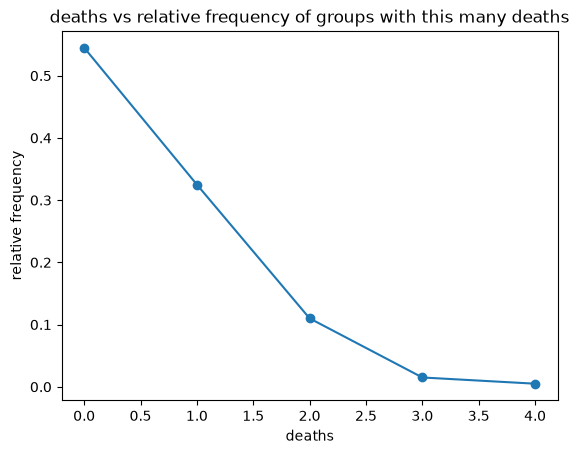

In [103]:
# part 1
deaths = np.array([0, 1, 2, 3, 4])
relative_freq = np.array([0.545, 0.325, 0.11, 0.015, 0.005])
plt.plot(deaths, relative_freq, marker='o')
plt.xlabel("deaths")
plt.ylabel("relative frequency")
plt.title("deaths vs relative frequency of groups with this many deaths")
plt.show()

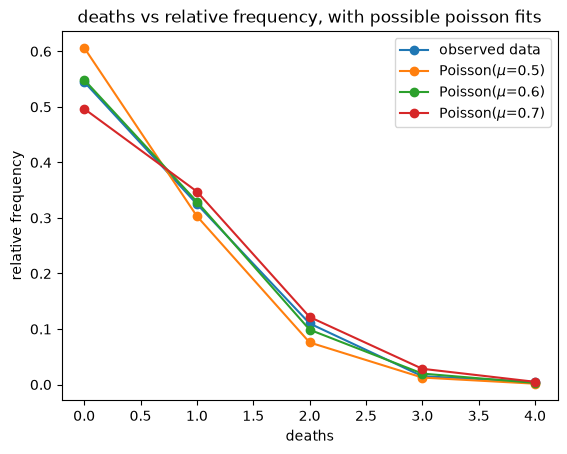

In [104]:
# part 2
mus = np.array([0.5, 0.6, 0.7]) #mu guesses
poisson = stats.poisson.pmf(deaths, mus[:, None]) #poisson object
plt.plot(deaths, relative_freq, marker='o')
plt.plot(deaths, poisson.T, marker='o')
plt.xlabel("deaths")
plt.ylabel("relative frequency")
plt.title("deaths vs relative frequency, with possible poisson fits")
plt.legend(['observed data'] + [f'Poisson($\\mu$={mu})' for mu in mus])
plt.show()

In [105]:
# part 3
groups = np.array([109, 65, 22, 3, 1])
data = np.repeat(deaths, groups) #repeats "deaths" "group" # of times
sample_mean = np.mean(data) #mean
sample_var = np.var(data, ddof=1) #variance
 
weighted_mean = np.sum(deaths * relative_freq)
weighted_var = np.sum(relative_freq * (deaths - weighted_mean)**2)

print("mean:", sample_mean)
print("variance:", sample_var)
print("weighted mean:", weighted_mean)
print("weighted variance:", weighted_var)
print("for a poisson distribtution, mean=variance=mu")
possible_mus = ([sample_mean, sample_var, weighted_mean, weighted_var])
found_mu = np.average(possible_mus)
print(found_mu)

mean: 0.61
variance: 0.6109547738693468
weighted mean: 0.6100000000000001
weighted variance: 0.6079
for a poisson distribtution, mean=variance=mu
0.6097136934673367


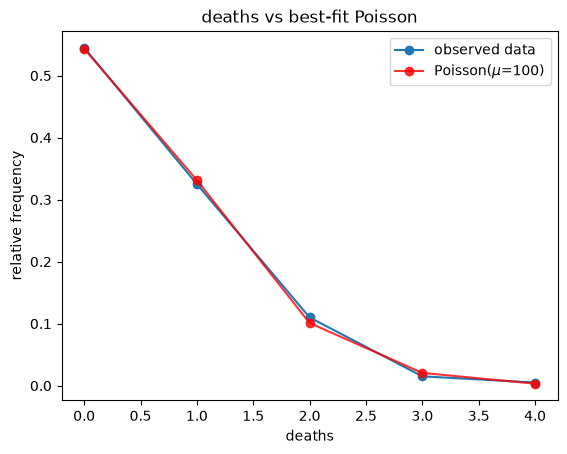

In [106]:
# part 4
poisson_pmf = stats.poisson.pmf(deaths, found_mu) #probability mass function
plt.plot(deaths, relative_freq, marker='o', label='observed data')
plt.plot(deaths, poisson_pmf, marker='o', color='red', label=f'Poisson($\\mu$={mu})', alpha=0.8)
plt.xlabel("deaths")
plt.ylabel("relative frequency")
plt.title("deaths vs best-fit Poisson")
plt.legend()
plt.show()

<span style="color:green">NP: correct! </span>